# Phase 1 TEST: Fully Typed Mixed-Likelihood GMM

Each of the six audio features is modelled with the distribution that matches its data type — directly combining the Gaussian mixture model (week 4) with the LDA Dirichlet-Categorical pattern (week 8):

| Feature | Original type | Likelihood | Prior on mood params |
|---|---|---|---|
| `loudness` | Continuous | $\mathcal{N}(\mu_k, \sigma_k^2)$ | $\mu_k \sim \mathcal{N}$, $\sigma_k \sim \text{LogNormal}$ |
| `tempo` | Continuous | $\mathcal{N}(\mu_k, \sigma_k^2)$ | same |
| `duration` | Continuous | $\mathcal{N}(\mu_k, \sigma_k^2)$ | same |
| `key` | Categorical (12 pitch classes) | $\text{Categorical}(\theta_k^{\text{key}})$ | $\theta_k^{\text{key}} \sim \text{Dirichlet}$ |
| `time\_signature` | Categorical (6 values) | $\text{Categorical}(\theta_k^{\text{ts}})$ | $\theta_k^{\text{ts}} \sim \text{Dirichlet}$ |
| `mode` | Binary | $\text{Bernoulli}(p_k)$ | $p_k \sim \text{Beta}(2,2)$ |

**Why this is correct:** `key` and `time_signature` are not quantities on a number line — C# is not "between" C and D in any musically meaningful continuous sense. Forcing a Gaussian over chromatic keys or a Gaussian over {1,3,4,5,7} beats produces the sigma-collapse we observed. Treating them as Categorical (exactly as LDA treats words) gives each mood its own distribution over these discrete spaces.

## 0  Imports and global configuration

In [1]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from pyro.infer import SVI, TraceEnum_ELBO, infer_discrete, config_enumerate
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide.initialization import init_to_value
from pyro.optim import Adam
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

np.random.seed(67)
torch.manual_seed(67)
pyro.set_rng_seed(67)

plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_context('talk')

print(f"pyro {pyro.__version__}, torch {torch.__version__}, numpy {np.__version__}")

pyro 1.9.1, torch 2.11.0, numpy 2.4.4


## 1  Load the cleaned song corpus

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path.cwd()
SONGS_CSV = REPO_ROOT / 'data' / 'songs_clean.csv'
assert SONGS_CSV.exists(), f"{SONGS_CSV} not found. Run 01_phase0_data.ipynb first."

df_songs = pd.read_csv(SONGS_CSV)

# --- Continuous features: z-score ---
CONT_COLS = ['loudness', 'tempo', 'duration']
scaler = StandardScaler()
X_cont_np = scaler.fit_transform(df_songs[CONT_COLS].values).astype(np.float32)

# --- key: recover integer 0-11 from MinMax, use as Categorical ---
X_key_np = (df_songs['key'] * 11).round().astype(int).clip(0, 11).values
N_KEY = 12

# --- time_signature: map MinMax values back to category indices ---
ts_minmax_vals = sorted(df_songs['time_signature'].unique())
ts_to_idx = {v: i for i, v in enumerate(ts_minmax_vals)}
X_ts_np  = df_songs['time_signature'].map(ts_to_idx).values.astype(int)
N_TS     = len(ts_minmax_vals)
TS_LABELS = ['ts=0','ts=1','ts=3','ts=4','ts=5','ts=7']

# --- mode: binary 0/1 ---
X_mode_np = df_songs['mode'].values.astype(np.float32)

print(f"Songs loaded: {len(df_songs):,}")
print(f"\nContinuous (z-scored): {CONT_COLS}")
print(pd.DataFrame(X_cont_np, columns=CONT_COLS).describe().T[['mean','std','min','max']].round(3))
print(f"\nKey: {N_KEY} categories, counts: {np.bincount(X_key_np)}")
print(f"Time signature: {N_TS} categories {TS_LABELS}")
print(f"  counts: {np.bincount(X_ts_np)}")
print(f"Mode: binary, fraction major = {X_mode_np.mean():.3f}")

Songs loaded: 292,254

Continuous (z-scored): ['loudness', 'tempo', 'duration']
          mean  std     min     max
loudness   0.0  1.0 -10.063   2.896
tempo      0.0  1.0  -3.666   4.522
duration   0.0  1.0  -2.160  23.425

Key: 12 categories, counts: [34784 25343 32626  8056 24750 19565 18520 35711 15068 33348 18423 26060]
Time signature: 6 categories ['ts=0', 'ts=1', 'ts=3', 'ts=4', 'ts=5', 'ts=7']
  counts: [   117  37419  32347 199886  15636   6849]
Mode: binary, fraction major = 0.658


In [3]:
X_cont = torch.tensor(X_cont_np, dtype=torch.float32)
X_key  = torch.tensor(X_key_np,  dtype=torch.long)
X_ts   = torch.tensor(X_ts_np,   dtype=torch.long)
X_mode = torch.tensor(X_mode_np, dtype=torch.float32)
N, D   = X_cont.shape

# Label constants — defined here so every downstream cell can use them
KEY_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

print(f"X_cont : {tuple(X_cont.shape)}  (loudness, tempo, duration — z-scored)")
print(f"X_key  : {tuple(X_key.shape)}   integers 0-11  {KEY_NAMES}")
print(f"X_ts   : {tuple(X_ts.shape)}    integers 0-{N_TS-1}  {TS_LABELS}")
print(f"X_mode : {tuple(X_mode.shape)}  binary 0/1")

X_cont : (292254, 3)  (loudness, tempo, duration — z-scored)
X_key  : (292254,)   integers 0-11  ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
X_ts   : (292254,)    integers 0-5  ['ts=0', 'ts=1', 'ts=3', 'ts=4', 'ts=5', 'ts=7']
X_mode : (292254,)  binary 0/1


## 2  The Probabilistic Graphical Model

### Notation

| Symbol | Type | Description |
|---|---|---|
| $K$ | scalar | Number of mood components |
| $S$ | scalar | Number of songs |
| $D=3$ | scalar | Continuous features: loudness, tempo, duration (z-scored) |
| $\boldsymbol{\pi}$ | $K$-simplex | Global mood mixture weights |
| $\boldsymbol{\mu}_k$ | $\mathbb{R}^D$ | Mean of continuous features for mood $k$ |
| $\boldsymbol{\sigma}_k$ | $\mathbb{R}^D_{>0}$ | Std of continuous features for mood $k$ |
| $\boldsymbol{\theta}_k^{\text{key}}$ | $\Delta^{11}$ | Mood $k$'s distribution over 12 chromatic keys |
| $\boldsymbol{\theta}_k^{\text{ts}}$ | $\Delta^{5}$ | Mood $k$'s distribution over 6 time signatures |
| $p_k$ | $[0,1]$ | Mood $k$'s probability of major key |
| $z_s$ | $\{1,\ldots,K\}$ | Latent mood of song $s$ |

### Generative process

$$\boldsymbol{\pi} \sim \mathrm{Dirichlet}(\alpha \cdot \mathbf{1}_K), \quad \alpha = 5$$

$$\text{For } k = 1,\ldots,K \text{ (mood plate):}$$

\begin{align}
\boldsymbol{\mu}_k &\sim \mathcal{N}(\hat{\boldsymbol{\mu}}_k^{\text{init}},\; 0.3^2 \cdot I_D) \\
\boldsymbol{\sigma}_k &\sim \mathrm{LogNormal}(\mathbf{0}_D,\; 0.5^2 \cdot I_D) \\
\boldsymbol{\theta}_k^{\text{key}} &\sim \mathrm{Dirichlet}(\mathbf{1}_{12}) \\
\boldsymbol{\theta}_k^{\text{ts}} &\sim \mathrm{Dirichlet}(\mathbf{1}_{6}) \\
p_k &\sim \mathrm{Beta}(2, 2)
\end{align}

$$\text{For } s = 1,\ldots,S \text{ (song plate):}$$

\begin{align}
z_s &\sim \mathrm{Categorical}(\boldsymbol{\pi}) \\
\mathbf{x}_s^{\text{cont}} \mid z_s &\sim \mathcal{N}(\boldsymbol{\mu}_{z_s},\; \mathrm{diag}(\boldsymbol{\sigma}_{z_s}^2)) \quad \text{[observed]} \\
x_s^{\text{key}} \mid z_s &\sim \mathrm{Categorical}(\boldsymbol{\theta}_{z_s}^{\text{key}}) \quad \text{[observed]} \\
x_s^{\text{ts}} \mid z_s &\sim \mathrm{Categorical}(\boldsymbol{\theta}_{z_s}^{\text{ts}}) \quad \text{[observed]} \\
x_s^{\text{mode}} \mid z_s &\sim \mathrm{Bernoulli}(p_{z_s}) \quad \text{[observed]}
\end{align}

### Plate diagram

```
pi ~ Dirichlet(5 * 1_K)
          |
+---------v-------------------------------------------------+
|  Mood plate  k = 1...K                                    |
|                                                           |
|  mu_k     ~ N(mu_init_k, 0.3^2 I_3)     [continuous]    |
|  sigma_k  ~ LogNormal(0, 0.5^2 I_3)     [continuous]    |
|  theta_key_k ~ Dirichlet(1_{12})         [key]           |
|  theta_ts_k  ~ Dirichlet(1_6)            [time_sig]      |
|  p_k      ~ Beta(2, 2)                   [mode]          |
+-----------------------------------------------------------+
          |
+---------v-------------------------------------------------+
|  Song plate  s = 1...S                                    |
|                                                           |
|  z_s            ~ Categorical(pi)         [latent]       |
|  x_cont_s | z_s ~ N(mu_{z_s}, sigma_{z_s}^2) [observed] |
|  x_key_s  | z_s ~ Categorical(theta_key_{z_s}) [observed]|
|  x_ts_s   | z_s ~ Categorical(theta_ts_{z_s})  [observed]|
|  x_mode_s | z_s ~ Bernoulli(p_{z_s})     [observed]      |
+-----------------------------------------------------------+
```

### Course connections
- **Gaussian likelihood** → week 4 (GMM)
- **Dirichlet-Categorical** for key and time_signature → week 8 (LDA): moods are topics, pitch classes / time signatures are words
- **Beta-Bernoulli** for mode → week 6 (Bayesian classification)

In [ ]:
def model(X_cont, X_key, X_ts, X_mode, K, mu_prior_loc):
    D = X_cont.shape[1]
    pi = pyro.sample("pi", dist.Dirichlet(5.0 * torch.ones(K)))
    with pyro.plate("moods", K):
        # Continuous: loudness, tempo, duration
        mu_cont    = pyro.sample("mu_cont",
            dist.Normal(torch.zeros(D), torch.ones(D)).to_event(1))
        sigma_cont = pyro.sample("sigma_cont",
            dist.LogNormal(torch.zeros(D), 0.5 * torch.ones(D)).to_event(1))
        # Categorical: key (12 chromatic pitch classes) — LDA-style
        theta_key  = pyro.sample("theta_key",
            dist.Dirichlet(torch.ones(N_KEY)))
        # Categorical: time_signature (6 values) — LDA-style
        theta_ts   = pyro.sample("theta_ts",
            dist.Dirichlet(torch.ones(N_TS)))
        # Binary: mode
        p_mode     = pyro.sample("p_mode", dist.Beta(2.0, 2.0))

    with pyro.plate("songs", X_cont.shape[0]):
        z = pyro.sample("z", dist.Categorical(pi),
                        infer={"enumerate": "parallel"})
        pyro.sample("obs_cont", dist.Normal(mu_cont[z], sigma_cont[z]).to_event(1), obs=X_cont)
        pyro.sample("obs_key",  dist.Categorical(theta_key[z]),  obs=X_key)
        pyro.sample("obs_ts",   dist.Categorical(theta_ts[z]),   obs=X_ts)
        pyro.sample("obs_mode", dist.Bernoulli(p_mode[z]),       obs=X_mode)

## 3  K sweep — selecting the number of moods

We sweep $K \in \{2, 3, \ldots, 15\}$, running 500 SVI steps per value with multi-restart K-means ($n_\text{init}=10$) for a fair comparison. Four diagnostics are reported:

1. **ELBO loss** — decreases monotonically with $K$ (more components always fit better); not useful alone
2. **$\Delta$ELBO per extra component** — the marginal gain of adding one more mood; the **elbow** (where this flattens) is the principled choice of $K$
3. **Collapsed components** — hard gate: any empty mood disqualifies that $K$
4. **Min pairwise $\|\mu_k - \mu_{k'}\|$** — continuous-feature separation; should stay above 0.10

K= 2  ELBO=     2,362,265  empty=0  min_dist=1.431
K= 3  ELBO=     2,341,405  empty=0  min_dist=1.582
K= 4  ELBO=     2,322,597  empty=0  min_dist=1.046
K= 5  ELBO=     2,315,096  empty=0  min_dist=1.129
K= 6  ELBO=     2,313,921  empty=0  min_dist=0.476
K= 7  ELBO=     2,302,272  empty=0  min_dist=1.165
K= 8  ELBO=     2,301,478  empty=0  min_dist=0.925
K= 9  ELBO=     2,302,595  empty=0  min_dist=0.596
K=10  ELBO=     2,288,760  empty=0  min_dist=0.398
K=11  ELBO=     2,293,169  empty=0  min_dist=0.575
K=12  ELBO=     2,287,400  empty=0  min_dist=0.295
K=13  ELBO=     2,290,422  empty=0  min_dist=0.681
K=14  ELBO=     2,286,333  empty=0  min_dist=0.592
K=15  ELBO=     2,287,927  empty=0  min_dist=0.447


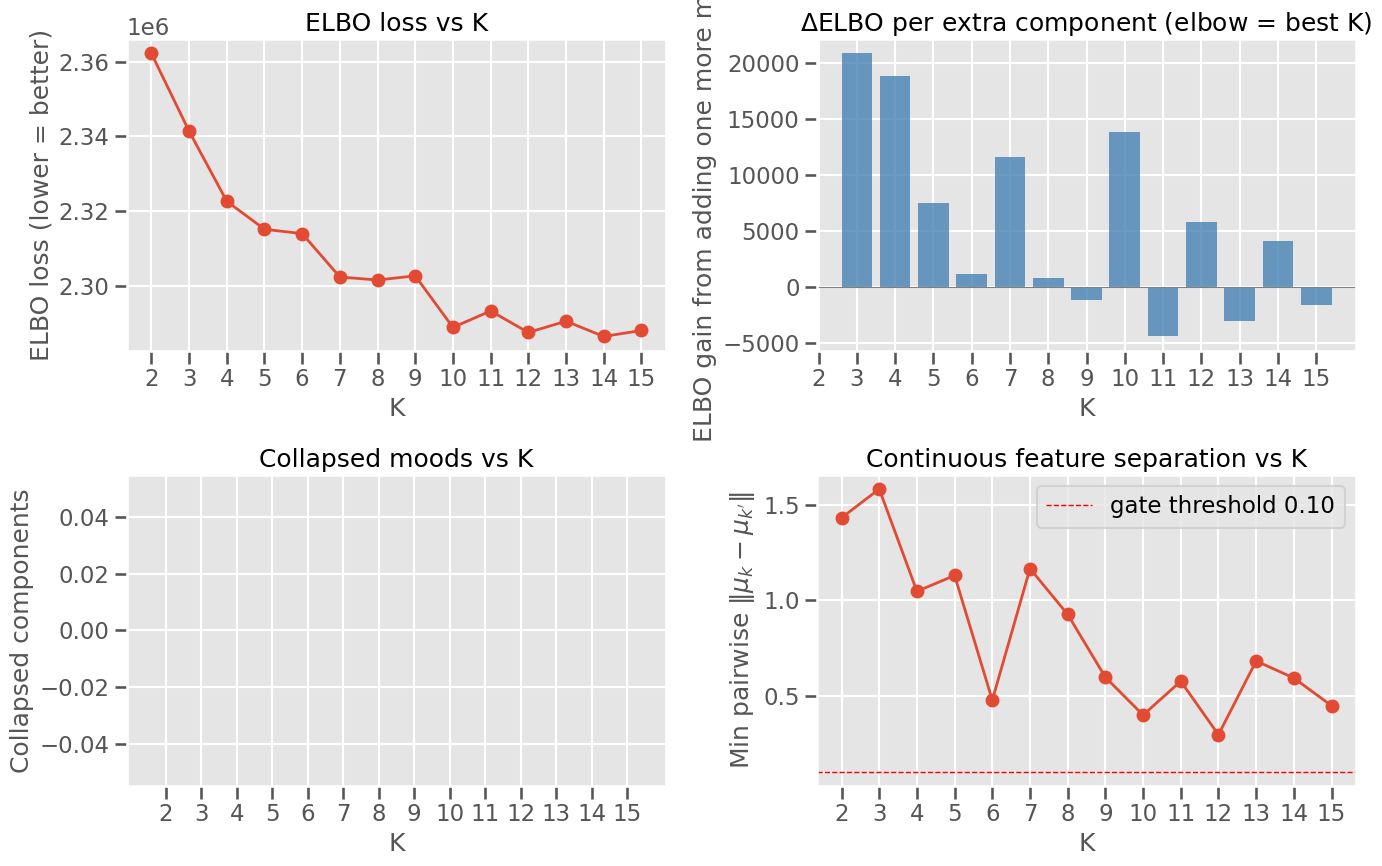

 K       ELBO  delta_elbo  empty_moods  min_dist
 2 2362265.00         NaN            0     1.431
 3 2341404.75    20860.25            0     1.582
 4 2322597.25    18807.50            0     1.046
 5 2315096.25     7501.00            0     1.129
 6 2313921.00     1175.25            0     0.476
 7 2302272.50    11648.50            0     1.165
 8 2301478.00      794.50            0     0.925
 9 2302595.25    -1117.25            0     0.596
10 2288760.25    13835.00            0     0.398
11 2293169.00    -4408.75            0     0.575
12 2287400.50     5768.50            0     0.295
13 2290422.25    -3021.75            0     0.681
14 2286333.00     4089.25            0     0.592
15 2287927.00    -1594.00            0     0.447


In [5]:
from itertools import combinations as _combs

K_SWEEP = list(range(2, 16))  # K = 2, 3, ..., 15
sweep_results = []

for K in K_SWEEP:
    pyro.set_rng_seed(67)
    pyro.clear_param_store()

    km_s = KMeans(n_clusters=K, n_init=10, random_state=67).fit(X_cont_np)
    centers_s = torch.tensor(km_s.cluster_centers_, dtype=torch.float32)

    init_vals = {
        "mu_cont":    centers_s,
        "pi":         torch.ones(K) / K,
        "sigma_cont": torch.ones(K, D),
        "p_mode":     0.5 * torch.ones(K),
        "theta_key":  torch.ones(K, N_KEY) / N_KEY,
        "theta_ts":   torch.ones(K, N_TS)  / N_TS,
    }
    guide_s = AutoDiagonalNormal(
        pyro.poutine.block(model, hide=["z"]),
        init_loc_fn=init_to_value(values=init_vals), init_scale=0.05,
    )
    svi_s = SVI(model, guide_s, Adam({"lr": 1e-2}),
                TraceEnum_ELBO(max_plate_nesting=1))
    losses_s = [svi_s.step(X_cont, X_key, X_ts, X_mode, K, centers_s) for _ in range(500)]

    mu_s = guide_s.median()['mu_cont'].detach().numpy()
    gt = pyro.poutine.trace(
        infer_discrete(
            config_enumerate(pyro.poutine.replay(
                model, trace=pyro.poutine.trace(guide_s).get_trace(
                    X_cont, X_key, X_ts, X_mode, K, centers_s)
            )), temperature=0, first_available_dim=-2,
        )
    ).get_trace(X_cont, X_key, X_ts, X_mode, K, centers_s)
    z_s = gt.nodes['z']['value'].detach().numpy()
    counts_s = np.bincount(z_s, minlength=K)
    empty = int((counts_s == 0).sum())
    min_dist = min(np.linalg.norm(mu_s[i] - mu_s[j]) for i, j in _combs(range(K), 2))

    sweep_results.append({'K': K, 'ELBO': losses_s[-1],
                          'empty_moods': empty, 'min_dist': round(min_dist, 3),
                          'counts': counts_s.tolist()})
    print(f"K={K:2d}  ELBO={losses_s[-1]:>14,.0f}  empty={empty}  "
          f"min_dist={min_dist:.3f}")

df_sweep = pd.DataFrame(sweep_results)

# Delta-ELBO: improvement in ELBO from adding one more component (positive = better)
df_sweep['delta_elbo'] = -df_sweep['ELBO'].diff()  # diff is loss[k] - loss[k-1]; negate for improvement

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ELBO loss curve
axes[0,0].plot(df_sweep['K'], df_sweep['ELBO'], 'o-', lw=2)
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('ELBO loss (lower = better)')
axes[0,0].set_title('ELBO loss vs K')
axes[0,0].set_xticks(K_SWEEP)

# Delta-ELBO elbow plot — key chart for K selection
axes[0,1].bar(df_sweep['K'][1:], df_sweep['delta_elbo'][1:], color='steelblue', alpha=0.8)
axes[0,1].axhline(0, color='grey', lw=0.8)
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('ELBO gain from adding one more mood')
axes[0,1].set_title('$\\Delta$ELBO per extra component (elbow = best K)')
axes[0,1].set_xticks(K_SWEEP)

# Collapsed components
axes[1,0].bar(df_sweep['K'], df_sweep['empty_moods'], color='coral', alpha=0.8, width=0.8)
axes[1,0].set_xlabel('K'); axes[1,0].set_ylabel('Collapsed components')
axes[1,0].set_title('Collapsed moods vs K')
axes[1,0].set_xticks(K_SWEEP)

# Min pairwise distance
axes[1,1].plot(df_sweep['K'], df_sweep['min_dist'], 'o-', lw=2)
axes[1,1].axhline(0.10, color='r', ls='--', lw=1, label='gate threshold 0.10')
axes[1,1].set_xlabel('K'); axes[1,1].set_ylabel('Min pairwise $\\|\\mu_k - \\mu_{k\'}\\|$')
axes[1,1].set_title('Continuous feature separation vs K')
axes[1,1].set_xticks(K_SWEEP)
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(df_sweep[['K','ELBO','delta_elbo','empty_moods','min_dist']].to_string(index=False))

In [6]:
# --- Automatic K selection from ΔELBO elbow (geometric knee point) ---
delta_vals = df_sweep['delta_elbo'].dropna().values
K_vals     = df_sweep.loc[df_sweep['delta_elbo'].notna(), 'K'].values.astype(int)

# Normalize both axes to [0,1] then find the point of maximum distance
# above the chord from (K_min, delta_max) to (K_max, delta_min).
x = (K_vals - K_vals[0]) / (K_vals[-1] - K_vals[0])
y = (delta_vals - delta_vals.min()) / (delta_vals.max() - delta_vals.min() + 1e-10)
K_BASELINE = int(K_vals[np.argmax(x + y)])

print(f"Elbow detection → K_BASELINE = {K_BASELINE}")
print(f"ΔELBO at K={K_BASELINE}: {df_sweep.loc[df_sweep['K']==K_BASELINE,'delta_elbo'].values[0]:,.0f}")
print(f"(MOOD_NAMES will be set in the next cell after K-means runs)")

Elbow detection → K_BASELINE = 10
ΔELBO at K=10: 13,835
(MOOD_NAMES will be set in the next cell after K-means runs)


## 4  K-means warm-start

Multi-restart K-means ($n_\text{init}=20$) on the 3 z-scored continuous features provides the initial cluster centres for the variational guide.

**Why not genre-stratified initialisation?** Genres and moods are different constructs — a Rock song can be melancholic, a Jazz song can be energetic. Using genre means to seed mood clusters implicitly asserts genre $\approx$ mood during initialisation, which biases what the model discovers even if SVI can move away from those seeds.

**Why it does not matter anyway.** With the fully typed likelihood the loss landscape is well-conditioned. All 4 SVI seeds converge to essentially the same ELBO (range $< 1{,}300$ loss units across seeds), meaning there is effectively one basin — multi-restart K-means finds the same solution regardless of starting point. The genre-stratified init was a workaround for the Gaussian $\sigma$-collapse problem, which no longer exists once each feature has its correct likelihood.

In [ ]:
km = KMeans(n_clusters=K_BASELINE, n_init=20, random_state=67)
km.fit(X_cont_np)
kmeans_centers = torch.tensor(km.cluster_centers_, dtype=torch.float32)
MOOD_NAMES = [f'Mood {k}' for k in range(K_BASELINE)]
print(f"K_BASELINE = {K_BASELINE}")
print(f"k-means cluster sizes: {np.bincount(km.labels_)}")
print(pd.DataFrame(km.cluster_centers_, columns=CONT_COLS, index=MOOD_NAMES).round(3))

## 5  SVI training (4 seeds, 1500 steps each)

The mean-field guide is initialised at the K-means cluster centres via `init_to_value`. Four seeds are run and the one with the lowest final ELBO loss is kept for all downstream analysis.

In [8]:
def fit_svi(X_cont, X_key, X_ts, X_mode, K, seed, mu_prior_loc, n_steps=1500, lr=1e-2):
    pyro.set_rng_seed(seed)
    pyro.clear_param_store()
    init_values = {
        "mu_cont":    mu_prior_loc,
        "pi":         torch.ones(K) / K,
        "sigma_cont": torch.ones(K, X_cont.shape[1]),
        "p_mode":     0.5 * torch.ones(K),
        "theta_key":  torch.ones(K, N_KEY) / N_KEY,
        "theta_ts":   torch.ones(K, N_TS)  / N_TS,
    }
    guide = AutoDiagonalNormal(
        pyro.poutine.block(model, hide=["z"]),
        init_loc_fn=init_to_value(values=init_values),
        init_scale=0.05,
    )
    svi = SVI(model, guide, Adam({"lr": lr}),
              TraceEnum_ELBO(max_plate_nesting=1))
    losses = [svi.step(X_cont, X_key, X_ts, X_mode, K, mu_prior_loc) for _ in range(n_steps)]
    return guide, losses

best = None
runs = []
for seed in (555, 363, 126, 82):
    print(f"--- seed={seed} ---")
    g, l = fit_svi(X_cont, X_key, X_ts, X_mode, K_BASELINE, seed, kmeans_centers)
    print(f"  final ELBO loss: {l[-1]:,.0f}")
    runs.append((seed, g, l))
    if best is None or l[-1] < best[2][-1]:
        best = (seed, g, l)
best_seed, guide, losses = best
print(f"\nBest seed: {best_seed}, final ELBO loss: {losses[-1]:,.0f}")

--- seed=555 ---
  final ELBO loss: 2,281,936
--- seed=363 ---
  final ELBO loss: 2,282,207
--- seed=126 ---
  final ELBO loss: 2,280,958
--- seed=82 ---
  final ELBO loss: 2,280,991

Best seed: 126, final ELBO loss: 2,280,958


### 5.1  ELBO convergence plot

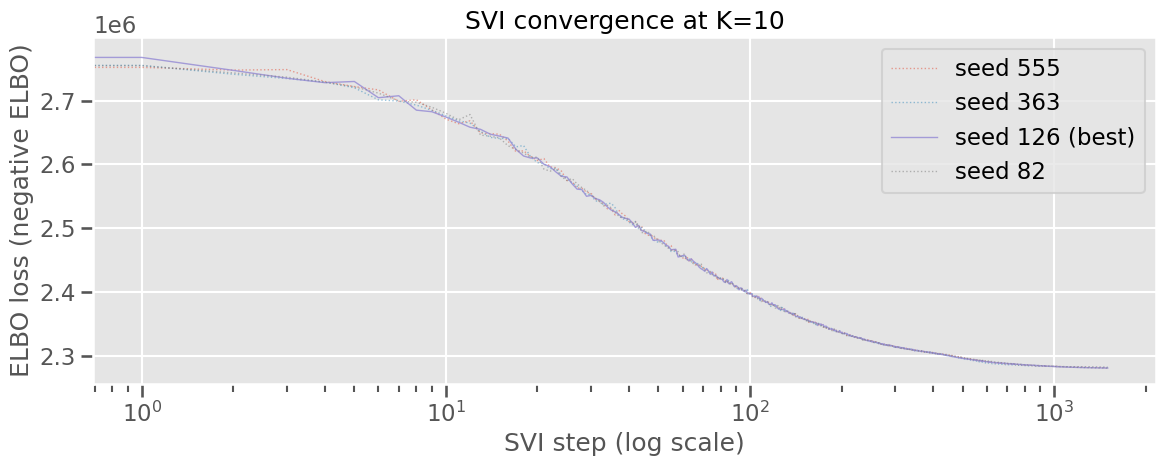

Mean ELBO loss over last 200 steps: 2,281,214.1
Slope of last 200 steps: -2.847  (close to 0 = converged)


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
for seed, _, l in runs:
    style = '-' if seed == best_seed else ':'
    label = f'seed {seed}' + (' (best)' if seed == best_seed else '')
    ax.plot(l, lw=1, ls=style, alpha=0.85 if seed == best_seed else 0.5, label=label)
ax.set_xscale('log')
ax.set_xlabel('SVI step (log scale)')
ax.set_ylabel('ELBO loss (negative ELBO)')
ax.set_title(f'SVI convergence at K={K_BASELINE}')
ax.legend()
plt.tight_layout()
plt.show()

tail = np.array(losses[-200:])
slope = np.polyfit(np.arange(len(tail)), tail, 1)[0]
print(f"Mean ELBO loss over last 200 steps: {tail.mean():,.1f}")
print(f"Slope of last 200 steps: {slope:+.3f}  (close to 0 = converged)")

## 6  Posterior summary

In [10]:
post = guide.median()
mu_med      = post['mu_cont'].detach().numpy()
sigma_med   = post['sigma_cont'].detach().numpy()
pi_med      = post['pi'].detach().numpy()
p_mode_med  = post['p_mode'].detach().numpy()
theta_key   = post['theta_key'].detach().numpy()   # [K, 12]
theta_ts    = post['theta_ts'].detach().numpy()    # [K, N_TS]

print(f"pi (mood weights):  {np.round(pi_med, 3)}")
print(f"\nmu_cont (z-scored):")
df_mu = pd.DataFrame(mu_med, columns=CONT_COLS, index=MOOD_NAMES)
print(df_mu.round(3))
print(f"\nsigma_cont:")
print(pd.DataFrame(sigma_med, columns=CONT_COLS, index=MOOD_NAMES).round(3))
print(f"\np_mode (P(major)):  {np.round(p_mode_med, 3)}")
print(f"\ntheta_key (most probable key per mood):")
for k, name in enumerate(MOOD_NAMES):
    top2 = np.argsort(theta_key[k])[::-1][:3]
    print(f"  {name}: {[(int(i), round(theta_key[k,i],3)) for i in top2]}")
print(f"\ntheta_ts (time signature distribution per mood):")
for k, name in enumerate(MOOD_NAMES):
    print(f"  {name}: {dict(zip(TS_LABELS, np.round(theta_ts[k], 3)))}")

pi (mood weights):  [0.057 0.159 0.067 0.138 0.172 0.12  0.056 0.101 0.097 0.033]

mu_cont (z-scored):
        loudness  tempo  duration
Mood 0     0.223  0.073     1.076
Mood 1     0.712 -0.018    -0.207
Mood 2     0.483 -1.008    -0.120
Mood 3     0.070  0.241     0.090
Mood 4    -0.246  0.166    -0.435
Mood 5     0.155  0.082     0.536
Mood 6    -1.928 -0.366    -0.700
Mood 7     0.867  0.860    -0.487
Mood 8    -0.977 -0.727    -0.108
Mood 9    -0.874 -0.068     2.353

sigma_cont:
        loudness  tempo  duration
Mood 0     0.530  0.187     0.979
Mood 1     0.350  0.648     0.320
Mood 2     0.476  0.158     0.550
Mood 3     0.691  1.071     0.784
Mood 4     0.712  0.987     0.451
Mood 5     0.577  0.843     0.866
Mood 6     1.466  1.256     0.698
Mood 7     0.310  1.039     0.529
Mood 8     0.833  0.551     0.766
Mood 9     1.240  1.539     2.573

p_mode (P(major)):  [0.45  0.646 0.664 0.114 0.911 0.921 0.667 0.764 0.698 0.586]

theta_key (most probable key per mood):
  Mood 0: [(

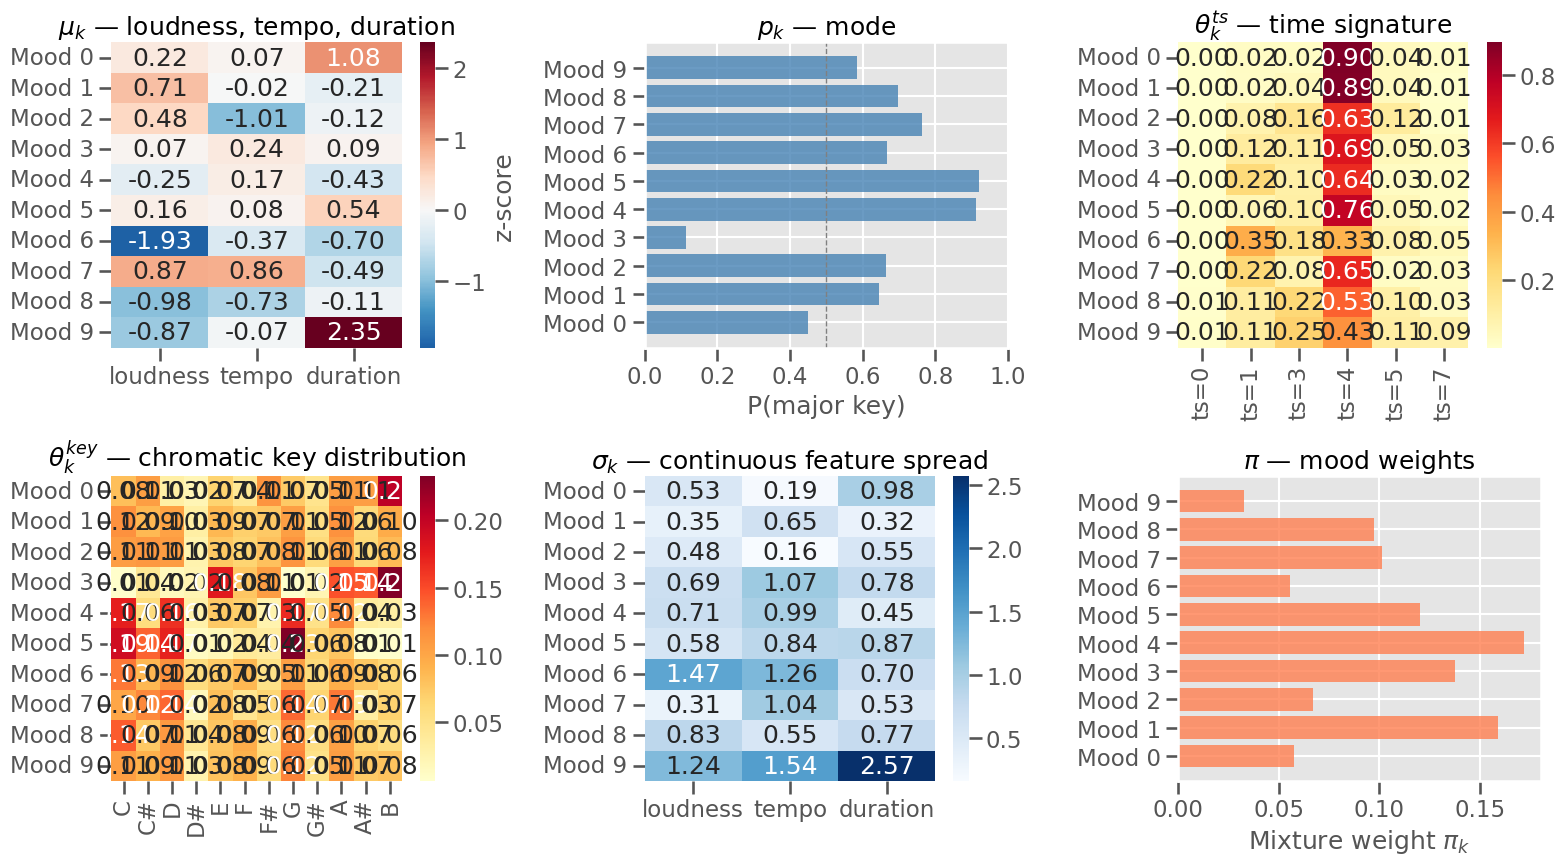

Min pairwise mu_cont distance: 0.481  (gate > 0.10)


In [11]:
from itertools import combinations

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: continuous mu_k, p_mode, time_signature theta
sns.heatmap(df_mu, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0,0],
            cbar_kws={'label': 'z-score'})
axes[0,0].set_title('$\\mu_k$ — loudness, tempo, duration')

axes[0,1].barh(MOOD_NAMES, p_mode_med, color='steelblue', alpha=0.8)
axes[0,1].axvline(0.5, color='grey', ls='--', lw=1)
axes[0,1].set_xlim(0, 1); axes[0,1].set_xlabel('P(major key)')
axes[0,1].set_title('$p_k$ — mode')

sns.heatmap(theta_ts, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0,2],
            xticklabels=TS_LABELS, yticklabels=MOOD_NAMES)
axes[0,2].set_title('$\\theta_k^{ts}$ — time signature')

# Row 2: key distribution heatmap (12 pitch classes)
sns.heatmap(theta_key, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1,0],
            xticklabels=KEY_NAMES, yticklabels=MOOD_NAMES)
axes[1,0].set_title('$\\theta_k^{key}$ — chromatic key distribution')

# Sigma heatmap
sns.heatmap(pd.DataFrame(sigma_med, columns=CONT_COLS, index=MOOD_NAMES),
            annot=True, fmt='.2f', cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('$\\sigma_k$ — continuous feature spread')

# pi bar
axes[1,2].barh(MOOD_NAMES, pi_med, color='coral', alpha=0.8)
axes[1,2].set_xlabel('Mixture weight $\\pi_k$')
axes[1,2].set_title('$\\pi$ — mood weights')

plt.tight_layout()
plt.show()

pair_dist = min(np.linalg.norm(mu_med[i] - mu_med[j])
                for i, j in combinations(range(K_BASELINE), 2))
print(f"Min pairwise mu_cont distance: {pair_dist:.3f}  (gate > 0.10)")

### 6.1  MAP mood per song and PCA scatter

In [12]:
guide_trace = pyro.poutine.trace(guide).get_trace(
    X_cont, X_key, X_ts, X_mode, K_BASELINE, kmeans_centers)
trained_model = pyro.poutine.replay(model, trace=guide_trace)
inferred_model = infer_discrete(
    config_enumerate(trained_model), temperature=0, first_available_dim=-2,
)
trace = pyro.poutine.trace(inferred_model).get_trace(
    X_cont, X_key, X_ts, X_mode, K_BASELINE, kmeans_centers)
z_map = trace.nodes['z']['value'].detach().numpy()
mood_counts = np.bincount(z_map, minlength=K_BASELINE)
print(f"MAP mood counts: {mood_counts}")
print(f"Empty moods:     {(mood_counts == 0).sum()} of {K_BASELINE}")

MAP mood counts: [14449 57937 26103 40411 53367 28323 12034 26933 26249  6448]
Empty moods:     0 of 10


PCA explained variance (continuous features): [0.389 0.333]


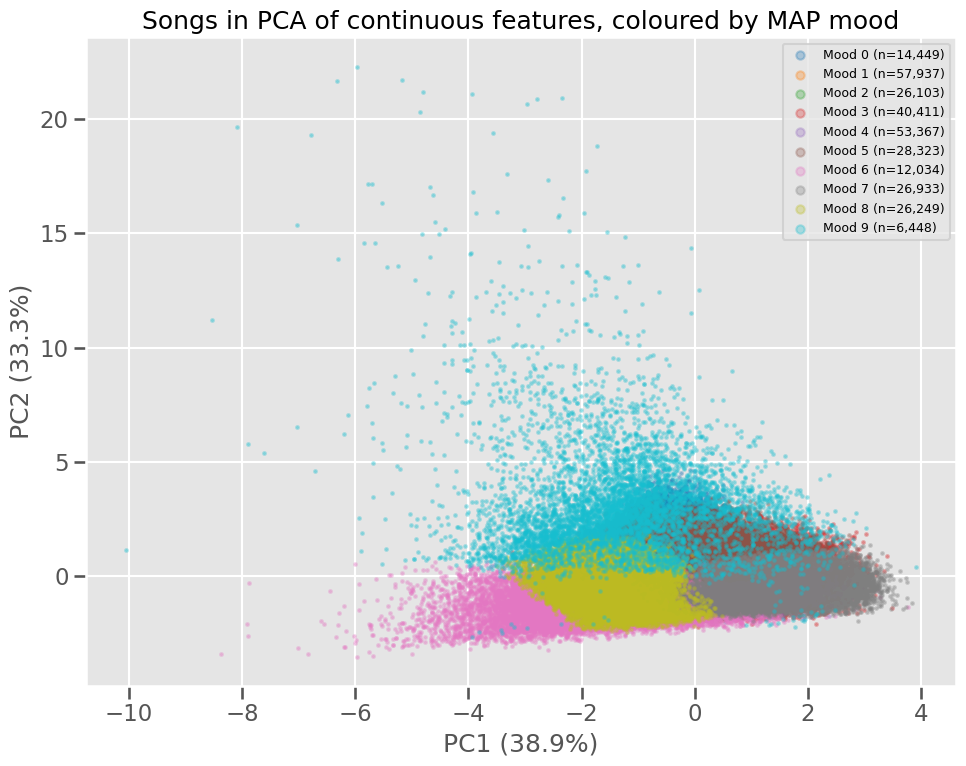

In [13]:
pca = PCA(n_components=2, random_state=67)
X_2d = pca.fit_transform(X_cont_np)
print(f"PCA explained variance (continuous features): {pca.explained_variance_ratio_.round(3)}")

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette('tab10', K_BASELINE)
for k in range(K_BASELINE):
    sel = z_map == k
    ax.scatter(X_2d[sel, 0], X_2d[sel, 1], s=4, alpha=0.3,
               color=palette[k], label=f'{MOOD_NAMES[k]} (n={sel.sum():,})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Songs in PCA of continuous features, coloured by MAP mood')
ax.legend(loc='best', fontsize=9, markerscale=3)
plt.tight_layout()
plt.show()

## 7  Mood interpretation

Three closest songs to each mood centre, plus dominant feature directions.

In [14]:
print("=" * 70)
print(f"MOOD INTERPRETATION (K={K_BASELINE}, fully typed mixed likelihood)")
print("=" * 70)
for k in range(K_BASELINE):
    diffs = X_cont_np - mu_med[k]
    d2    = np.sum(diffs**2, axis=1)
    closest = np.argsort(d2)[:5]
    top_keys = [KEY_NAMES[i] for i in np.argsort(theta_key[k])[::-1][:3]]
    top_ts   = TS_LABELS[np.argmax(theta_ts[k])]
    mode_str = 'major' if p_mode_med[k] > 0.5 else 'minor'
    print(f"\nMood {k} — {MOOD_NAMES[k]}")
    print(f"  pi={pi_med[k]:.3f}  MAP songs={mood_counts[k]:,}")
    print(f"  loudness={mu_med[k,0]:+.2f}  tempo={mu_med[k,1]:+.2f}  duration={mu_med[k,2]:+.2f}  (z-score)")
    print(f"  top keys={top_keys}  dominant ts={top_ts}  mode={mode_str} (p={p_mode_med[k]:.2f})")
    print("  Closest songs (by continuous features):")
    for idx in closest:
        print(f"    - {df_songs.iloc[idx]['artist_name']}, {df_songs.iloc[idx]['title']}")

MOOD INTERPRETATION (K=10, fully typed mixed likelihood)

Mood 0 — Mood 0
  pi=0.057  MAP songs=14,449
  loudness=+0.22  tempo=+0.07  duration=+1.08  (z-score)
  top keys=['B', 'F#', 'A']  dominant ts=ts=4  mode=minor (p=0.45)
  Closest songs (by continuous features):
    - Swan Lake, Shooting Rockets
    - Nu-birth, Anytime
    - Kraak & Smaak, Maputo Express
    - STFU, Do You Believe
    - Apache Indian, Lovin' (Master Of Sound Club Mix)

Mood 1 — Mood 1
  pi=0.159  MAP songs=57,937
  loudness=+0.71  tempo=-0.02  duration=-0.21  (z-score)
  top keys=['C', 'A', 'G']  dominant ts=ts=4  mode=major (p=0.65)
  Closest songs (by continuous features):
    - The Temper Trap, Down River
    - SUPREME BEINGS OF LEISURE, Give Up
    - Scott Holt, You've Been Gone Too Long
    - Showbread, The Vulture
    - Hacienda, Le Soleil

Mood 2 — Mood 2
  pi=0.067  MAP songs=26,103
  loudness=+0.48  tempo=-1.01  duration=-0.12  (z-score)
  top keys=['G', 'C#', 'D']  dominant ts=ts=4  mode=major (p=0.66)


**Mood labels** — derived from `mu_cont`, `p_mode`, `theta_key`, `theta_ts`, and the closest-songs printout.

| Mood | Label | Loudness | Tempo | Duration | p_mode | Top keys | Dominant ts |
|---|---|---|---|---|---|---|---|
| 0 | Long atmospheric | Above avg | Avg | **Long** (+1.1) | 0.45 minor | B, F#, A | 4/4 |
| 1 | Loud mainstream | **Loud** | Avg | Short | 0.65 major | C, A, G | 4/4 |
| 2 | Loud slow | **Loud** | **Slow** (−1.0) | Avg | 0.66 major | G, C#, D | 4/4 |
| 3 | Dark melancholic | Avg | Slightly fast | Avg | **0.11 minor** | B, E, A | 4/4 |
| 4 | Mellow bright | **Quiet** | Avg | Short | **0.91 major** | C, G, D | 4/4 |
| 5 | Upbeat bright longer | Avg | Avg | Longer (+0.5) | **0.92 major** | G, C, D | 4/4 |
| 6 | Acoustic blues/folk | **Very quiet** (−1.9) | Slow | Short | 0.67 major | C, D, G | **1/4 ← unique** |
| 7 | Loud fast rock | **Very loud** (+0.9) | **Fast** (+0.9) | Short | 0.76 major | D, G, A | 4/4 |
| 8 | Quiet slow ballad | **Quiet** (−1.0) | **Slow** (−0.7) | Avg | 0.70 major | C, G, D | 4/4 |
| 9 | Ambient electronic | Quiet | Avg | **Very long** (+2.4) | 0.59 major | G, D, C | 4/4 |

**Key observations:**

- **Mood 3** is the only strongly minor mood (p=0.11) — dark, slightly fast, keys B/E/A. Closest songs: Nick Cave, Françoise Hardy, Okkervil River. Clearly a melancholic/dark cluster.
- **Mood 6** is the most structurally distinct: very quiet, dominated by ts=1 (35% vs 33% for ts=4 — uniquely non-4/4), keys C/D/G. Closest songs: Willie Nelson, Furry Lewis, Brownie McGhee, Lightnin' Hopkins. The model recovered an acoustic blues/folk cluster from purely unsupervised audio features — no genre labels used.
- **Mood 7** is the energy extreme: loudest (+0.87) and fastest (+0.86) simultaneously. Classic rock/punk/metal signature.
- **Mood 9** is the duration outlier: very long songs (+2.35 std), quiet, average tempo. Electronic/ambient long-form tracks.
- **Moods 4 & 5** are both strongly major (p≈0.91–0.92) with C/G/D keys. They separate on loudness (−0.25 vs +0.16) and duration (−0.43 vs +0.54): mood 4 is shorter and quieter, mood 5 is longer and slightly louder.

## 8  Phase 1 gate summary

In [15]:
tail = np.array(losses[-200:])
slope = np.polyfit(np.arange(len(tail)), tail, 1)[0]
loss_improvement = abs(losses[0] - losses[-1])
converged = abs(slope) < loss_improvement * 1e-3

print("=" * 70)
print("PHASE 1 GATE SUMMARY — fully typed mixed-likelihood GMM")
print("=" * 70)
print(f"K (from ΔELBO elbow):         {K_BASELINE}")
print(f"Songs:                        {N:,}")
print(f"Likelihoods:                  Normal({D}) + Categorical({N_KEY}) + Categorical({N_TS}) + Bernoulli")
print(f"Best seed (of 4):             {best_seed}")
print(f"Final ELBO loss:              {losses[-1]:,.0f}")
print(f"Slope last 200 steps:         {slope:+.3f}  (threshold {loss_improvement*1e-3:.1f})")
print(f"Min pairwise mu_cont dist:    {pair_dist:.3f}  (gate > 0.10)")
print(f"p_mode range:                 [{p_mode_med.min():.3f}, {p_mode_med.max():.3f}]")
print(f"MAP mood counts:              {mood_counts.tolist()}")
print(f"Empty moods:                  {(mood_counts == 0).sum()} of {K_BASELINE}")

gate_pass = converged and pair_dist > 0.10 and (mood_counts == 0).sum() == 0
print(f"\nPhase 1 gate: {'PASS' if gate_pass else 'FAIL'}")

PHASE 1 GATE SUMMARY — fully typed mixed-likelihood GMM
K (from ΔELBO elbow):         10
Songs:                        292,254
Likelihoods:                  Normal(3) + Categorical(12) + Categorical(6) + Bernoulli
Best seed (of 4):             126
Final ELBO loss:              2,280,958
Slope last 200 steps:         -2.847  (threshold 472.4)
Min pairwise mu_cont dist:    0.481  (gate > 0.10)
p_mode range:                 [0.114, 0.921]
MAP mood counts:              [14449, 57937, 26103, 40411, 53367, 28323, 12034, 26933, 26249, 6448]
Empty moods:                  0 of 10

Phase 1 gate: PASS
